In [1]:
import sys
sys.path.insert(0, '../../..')
import random
import pandas as pd 
from importlib import reload
import MLPModel, LinearModel, Model_Training, DataDownload
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch

In [2]:


ticker = "BTC-USD"
start = '2019-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.001
tx_fees_bpts = 0
threshold = 0.001

weight_decay = 5e-3

max_lags = 24

modelMLP = MLPModel.MLP # multiplayer perception 

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series



In [3]:

def evaluate_seeds(
    model_factory,
    model_name,
    seeds,
):
    results = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        trained = Model_Training.model_training(
            model=model_factory(max_lags),
            tick=ticker,
            start=start,
            end=end,
            interval=interval,
            train_ratio=train_ratio,
            max_lags=max_lags,
            no_epochs=no_epoches,
            lr=lr,
            transaction_cost_bpts=tx_fees_bpts,
            weight_decay=weight_decay,
            trade_signal="threshold",
            threshold=threshold,
            verbose=False,
        )

        performance = trained.get_model_performance(
            trained.trade_results
        ).copy()

        performance["seed"] = seed
        performance["model"] = model_name
        results.append(performance)

    return pd.concat(
        results,
        ignore_index=True,
    )
    


In [4]:
def evaluate_seed_paths(
    model_factory,
    model_name,
    seeds,
    trainer_kwargs,
):
    metrics_list = []
    path_list = []
    max_lags = trainer_kwargs["max_lags"]
    for run, seed in enumerate(seeds):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        trained = Model_Training.model_training(
            model=model_factory(max_lags),
            **trainer_kwargs,
        )
        metrics = trained.get_model_performance(
            trained.trade_results
        ).copy()
        metrics["seed"] = seed
        metrics["model"] = model_name
        metrics_list.append(metrics)
        cumulative_return = np.expm1(
            trained.trade_results[
                "equity_log"
            ].to_numpy()
        ) * 100
        path = pd.Series(
            cumulative_return,
            index=trained.date_test,
            name=f"{model_name}_{run}_{seed}",
        )
        path_list.append(path)
    metrics_df = pd.concat(
        metrics_list,
        ignore_index=True,
    )
    paths_df = pd.concat(
        path_list,
        axis=1,
    )
    mean = paths_df.mean(axis=1)
    std = paths_df.std(axis=1)
    bands_df = pd.DataFrame(
        {
            "mean": mean,
            "std": std,
            "lower_1sigma": mean - std,
            "upper_1sigma": mean + std,
            "lower_2sigma": mean - 2 * std,
            "upper_2sigma": mean + 2 * std,
        }
    )
    return metrics_df, paths_df, bands_df

In [5]:
random_seeds = [random.randint(0,1_000_000) for _ in range(50)]  # pick 500 random seeds

# seed_MLP = evaluate_seeds(MLPModel.MLP,model_name = "MLP",seeds = random_seeds)
# seed_LIN = evaluate_seeds(LinearModel.LinearModel,model_name = "Linear",seeds = random_seeds) 
trainer_kwargs = {
    "tick": ticker,
    "start": start,
    "end": end,
    "interval": interval,
    "train_ratio": train_ratio,
    "max_lags": max_lags,
    "no_epochs": no_epoches,
    "lr": lr,
    "transaction_cost_bpts": tx_fees_bpts,
    "weight_decay": weight_decay,
    "trade_signal": "threshold",
    "threshold": threshold,
    "verbose": False,
}

mlp_metrics, mlp_paths, mlp_bands  = evaluate_seed_paths(MLPModel.MLP,model_name = "MLP",seeds = random_seeds, trainer_kwargs = trainer_kwargs)
lin_metrics, lin_paths, lin_bands = evaluate_seed_paths(LinearModel.LinearModel,model_name = "Linear",seeds = random_seeds, trainer_kwargs = trainer_kwargs) 



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

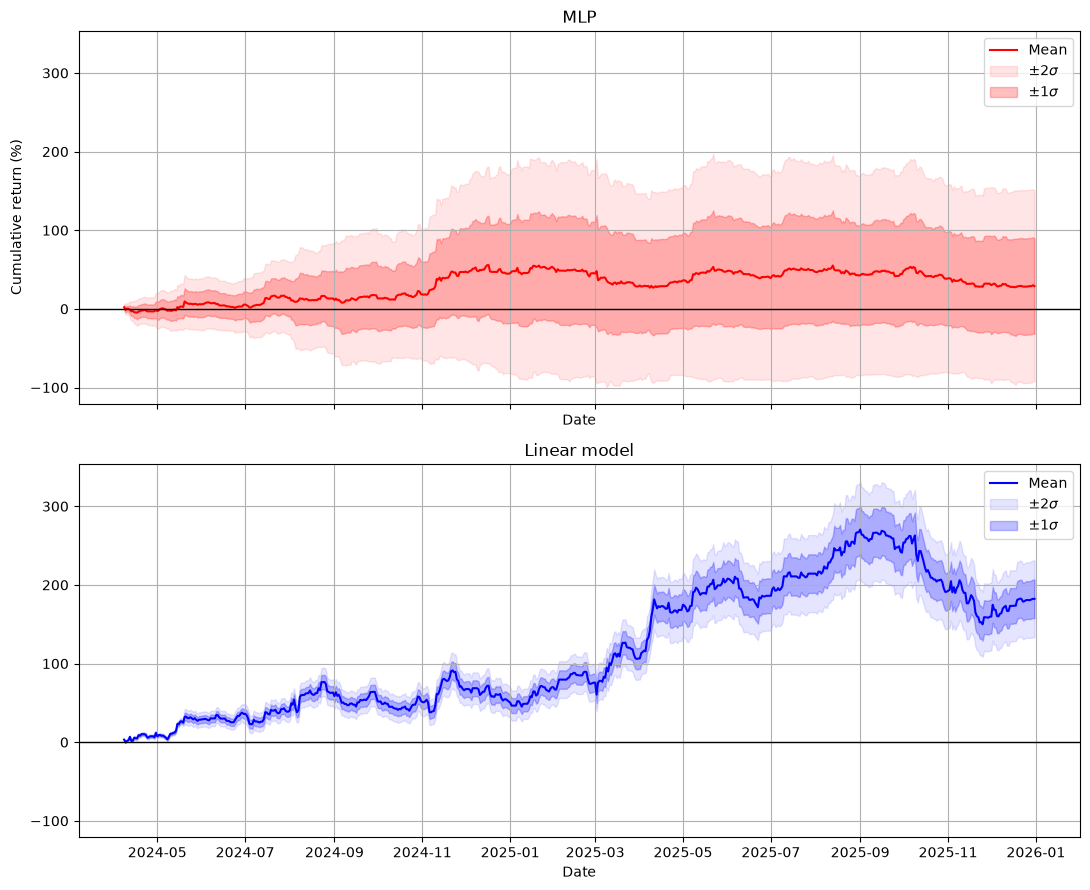

In [6]:
from matplotlib import pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
    sharey=True,
)

def plot_seed_bands(
    ax,
    bands,
    title,
    color,
):
    ax.plot(
        bands.index,
        bands["mean"],
        color=color,
        label="Mean",
    )

    ax.fill_between(
        bands.index,
        bands["lower_2sigma"],
        bands["upper_2sigma"],
        color=color,
        alpha=0.10,
        label=r"$\pm2\sigma$",
    )

    ax.fill_between(
        bands.index,
        bands["lower_1sigma"],
        bands["upper_1sigma"],
        color=color,
        alpha=0.25,
        label=r"$\pm1\sigma$",
    )

    ax.axhline(
        0,
        color="black",
        linewidth=1,
    )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.legend()

plot_seed_bands(
    ax1,
    mlp_bands,
    title="MLP",
    color="red",
)

plot_seed_bands(
    ax2,
    lin_bands,
    title="Linear model",
    color="blue",
)

ax1.set_ylabel("Cumulative return (%)")

fig.tight_layout()
plt.show()

In [7]:

# lags = [
#     1,
#     2,
#     4,
#     8,
#     16,
#     32,
# ]

lags = range(1,36,3)

lag_results = {
    "MLP": {},
    "Linear": {},
}

model_factories = {
    "MLP": MLPModel.MLP,
    "Linear": LinearModel.LinearModel,
}

for lag in lags:
    print(f"\nRunning lag {lag}...")

    lag_kwargs = trainer_kwargs.copy()
    lag_kwargs["max_lags"] = lag

    for model_name, model_factory in (
        model_factories.items()
    ):
        print(f"  {model_name}")

        metrics, paths, bands = (
            evaluate_seed_paths(
                model_factory=model_factory,
                model_name=model_name,
                seeds=random_seeds,
                trainer_kwargs=lag_kwargs,
            )
        )

        lag_results[model_name][lag] = {
            "metrics": metrics,
            "paths": paths,
            "bands": bands,
        }

[*********************100%***********************]  1 of 1 completed


Running lag 1...
  MLP



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/Users/stian/.venvs/nvim/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/stian/.venvs/nvim/lib/python3.14/site-packages/numpy/lib/_functio

  Linear


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******


Running lag 34...
  MLP


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

  Linear



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

In [8]:
# data = modelMLP(1)
Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)

data = Model.df

[*********************100%***********************]  1 of 1 completed


Training model...
Epoch 0/100000, Loss = 1.005575180
Epoch 500/100000, Loss = 0.772875667
Epoch 1000/100000, Loss = 0.697530866
Relative Tolance Reached at Epoch 1378

 Training Finished! 
 Loss = 0.658785462
Test Loss = 0.620752692

Test Loss = 0.000774861 
Train Loss = 0.000822274


In [9]:
import ipywidgets as widgets
import matplotlib.pyplot as plt


# data = 

def plot_selected_lag(lag):
    mlp_bands = lag_results[
        "MLP"
    ][lag]["bands"]

    lin_bands = lag_results[
        "Linear"
    ][lag]["bands"]

    # Underlying return aligned to each test period.
    underlying_returns = data[
        "close_log_return"
    ]

    if isinstance(
        underlying_returns,
        pd.DataFrame,
    ):
        underlying_returns = (
            underlying_returns.squeeze(
                "columns"
            )
        )

    underlying_returns = (
        underlying_returns
        .reindex(mlp_bands.index)
        .fillna(0.0)
    )

    underlying_cumulative = (
        np.expm1(
            underlying_returns.cumsum()
        )
        * 100
    )

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(11, 9),
        sharex=True,
        sharey=True,
    )
    fig.suptitle(ticker)

    plot_seed_bands(
        ax1,
        mlp_bands,
        title=f"MLP — lookback {lag}",
        color="red",
    )

    plot_seed_bands(
        ax2,
        lin_bands,
        title=f"Linear model — lookback {lag}",
        color="blue",
    )

    for ax in (ax1, ax2):
        ax.plot(
            underlying_cumulative.index,
            underlying_cumulative,
            color="black",
            linewidth=1.5,
            label="Underlying",
        )

        ax.set_ylabel(
            "Cumulative return (%)"
        )

        ax.legend()

    ax2.set_xlabel("Date")

    fig.tight_layout()
    plt.show()


widgets.interact(
    plot_selected_lag,
    lag=widgets.SelectionSlider(
        options=sorted(lags),
        value=sorted(lags)[0],
        description="Lookback:",
        continuous_update=False,
    ),
)

interactive(children=(SelectionSlider(continuous_update=False, description='Lookback:', options=(1, 4, 7, 10, …

<function __main__.plot_selected_lag(lag)>

In [10]:
from pathlib import Path

output_dir = Path(".")
output_dir.mkdir(exist_ok=True)

all_metrics = []
all_paths = []
all_bands = []

for model_name, model_results in (
    lag_results.items()
):
    for lag, result in model_results.items():
        # Metrics
        metrics = result["metrics"].copy()
        metrics["model"] = model_name
        metrics["lag"] = lag
        all_metrics.append(metrics)

        # Individual seed paths: wide → long format
        paths = (
            result["paths"]
            .rename_axis("date")
            .reset_index()
            .melt(
                id_vars="date",
                var_name="seed_run",
                value_name="cumulative_return",
            )
        )

        paths["model"] = model_name
        paths["lag"] = lag
        all_paths.append(paths)

        # Mean and sigma bands
        bands = (
            result["bands"]
            .rename_axis("date")
            .reset_index()
        )

        bands["model"] = model_name
        bands["lag"] = lag
        all_bands.append(bands)

metrics_csv = pd.concat(
    all_metrics,
    ignore_index=True,
)

paths_csv = pd.concat(
    all_paths,
    ignore_index=True,
)

bands_csv = pd.concat(
    all_bands,
    ignore_index=True,
)

metrics_csv.to_csv(
    output_dir / "seed_metrics.csv",
    index=False,
)

paths_csv.to_csv(
    output_dir / "seed_paths.csv",
    index=False,
)

bands_csv.to_csv(
    output_dir / "seed_bands.csv",
    index=False,
)

In [11]:
cumulative_log_return = (
    data["close_log_return"]
    .cumsum()
    .rename("cumulative_log_return")
)

cumulative_log_return.to_csv(
    "cumulative_log_return.csv",
    index=True,
)